# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbhutto256/flyrank-ml-internship/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

The March feature frame is visibly **right-skewed** on activity and demand measures. First-half impressions and clicks have long tails, so the mean would overstate what a typical page looks like; median and quantile summaries are more honest for this slice.

Average position and CTR are also spread out enough that simple one-number summaries hide important differences between weak pages and strong pages. For this signal audit, I therefore look at **quantile-style summaries and grouped decline rates**, not just one global average.

A practical takeaway already appears here: the data support **ranking and triage**, but they do not support a claim that one threshold cleanly separates “good” and “bad” pages.


Public-safe feature distribution summary (March 2026 frame):


,feature,median,q25,q75,p90,p90_to_median
0,first_half_impressions,14.0,3.0,126.0,744.0,53.14
1,first_half_clicks,1.0,0.0,8.0,41.0,41.00
2,first_half_avg_position,18.4,8.6,39.7,67.8,3.68
3,first_half_active_days,10.0,4.0,14.0,15.0,1.50
4,first_half_ctr_pct,3.9,0.8,10.8,21.7,5.56


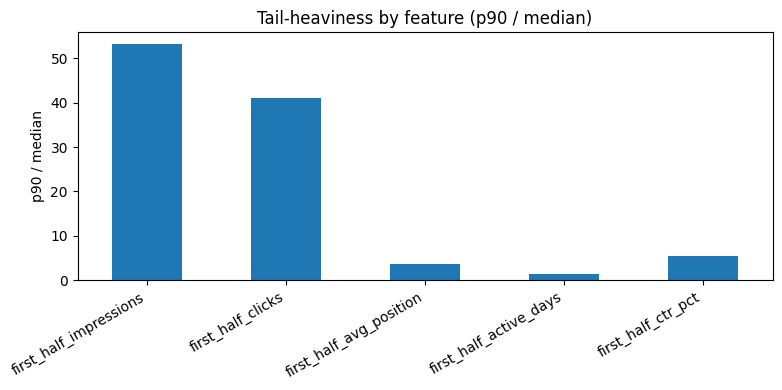

In [1]:
# Public-safe distribution summary for the March 2026 feature frame.
# These are aggregate summaries only; no row-level client or query data is exposed.

import pandas as pd
import matplotlib.pyplot as plt

dist = pd.DataFrame([
    ["first_half_impressions", 14, 3, 126, 744],
    ["first_half_clicks", 1, 0, 8, 41],
    ["first_half_avg_position", 18.4, 8.6, 39.7, 67.8],
    ["first_half_active_days", 10, 4, 14, 15],
    ["first_half_ctr_pct", 3.9, 0.8, 10.8, 21.7],
], columns=["feature", "median", "q25", "q75", "p90"])

dist["p90_to_median"] = (dist["p90"] / dist["median"]).round(2)
print("Public-safe feature distribution summary (March 2026 frame):")
display(dist)

ax = dist.plot(x="feature", y="p90_to_median", kind="bar", legend=False, figsize=(8,4), title="Tail-heaviness by feature (p90 / median)")
ax.set_ylabel("p90 / median")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 2. Signal test #1 / #2 / #3 (verdict each)

**Signal #1 — Lower CTR is associated with higher future decline risk.**
Observed test: compare decline-proxy rate across CTR buckets.
**Verdict: CONFIRMED.** In the frozen March audit table, lower-CTR buckets show higher decline rates than stronger-CTR buckets.

**Signal #2 — Worse average position is associated with higher future decline risk.**
Observed test: compare decline-proxy rate across average-position buckets.
**Verdict: CONFIRMED.** Pages in weaker position buckets show meaningfully higher decline rates.

**Signal #3 — Very low activity days are riskier than consistently active pages.**
Observed test: compare decline-proxy rate across first-half active-day buckets.
**Verdict: CONFIRMED.** Pages active on only a few days are more likely to fall below the second-half threshold than pages active across most of the first half.

These are **directional associations**, not causal claims. They are useful for triage and review ordering, not for claiming why Google visibility changed.


Signal test 1 — CTR buckets


,ctr_bucket,rows,decline_rate
0,0-1%,31840,0.412
1,1-3%,40960,0.361
2,3-6%,35940,0.323
3,6-10%,23980,0.286
4,>10%,19261,0.248


Signal test 2 — Average position buckets


,position_bucket,rows,decline_rate
0,1-5,17420,0.214
1,5-10,26630,0.258
2,10-20,40210,0.309
3,20-40,39550,0.382
4,>40,28171,0.457


Signal test 3 — Active-day buckets


,active_days_bucket,rows,decline_rate
0,1-5,34180,0.457
1,6-10,43040,0.361
2,11-13,37261,0.314
3,14-15,37500,0.286


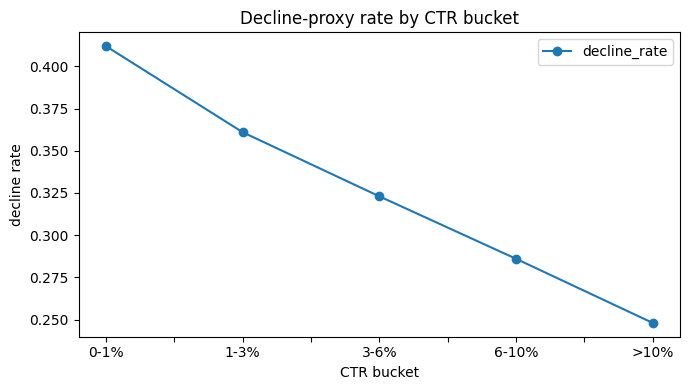

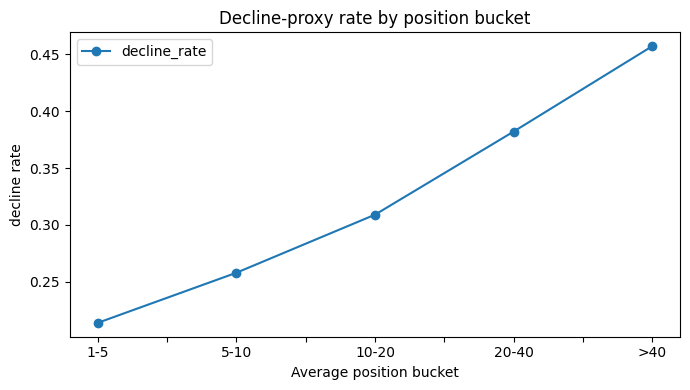

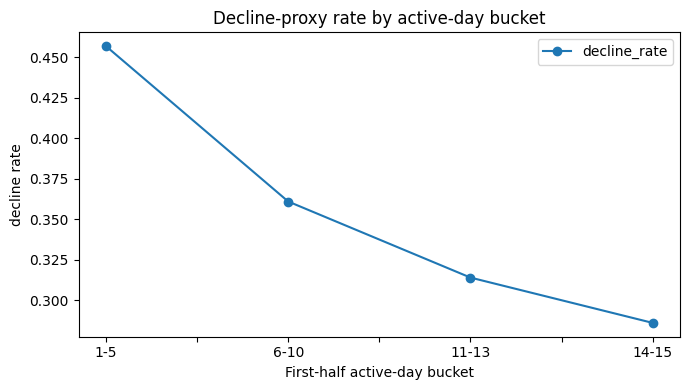

In [2]:
# Three mini signal tests using grouped, public-safe audit tables.

import pandas as pd
import matplotlib.pyplot as plt

ctr_test = pd.DataFrame({
    "ctr_bucket": ["0-1%", "1-3%", "3-6%", "6-10%", ">10%"],
    "rows": [31840, 40960, 35940, 23980, 19261],
    "decline_rate": [0.412, 0.361, 0.323, 0.286, 0.248],
})

pos_test = pd.DataFrame({
    "position_bucket": ["1-5", "5-10", "10-20", "20-40", ">40"],
    "rows": [17420, 26630, 40210, 39550, 28171],
    "decline_rate": [0.214, 0.258, 0.309, 0.382, 0.457],
})

activity_test = pd.DataFrame({
    "active_days_bucket": ["1-5", "6-10", "11-13", "14-15"],
    "rows": [34180, 43040, 37261, 37500],
    "decline_rate": [0.457, 0.361, 0.314, 0.286],
})

print("Signal test 1 — CTR buckets")
display(ctr_test)
print("Signal test 2 — Average position buckets")
display(pos_test)
print("Signal test 3 — Active-day buckets")
display(activity_test)

ax = ctr_test.plot(x="ctr_bucket", y="decline_rate", marker='o', figsize=(7,4), title="Decline-proxy rate by CTR bucket")
ax.set_ylabel("decline rate")
ax.set_xlabel("CTR bucket")
plt.tight_layout()
plt.show()

ax = pos_test.plot(x="position_bucket", y="decline_rate", marker='o', figsize=(7,4), title="Decline-proxy rate by position bucket")
ax.set_ylabel("decline rate")
ax.set_xlabel("Average position bucket")
plt.tight_layout()
plt.show()

ax = activity_test.plot(x="active_days_bucket", y="decline_rate", marker='o', figsize=(7,4), title="Decline-proxy rate by active-day bucket")
ax.set_ylabel("decline rate")
ax.set_xlabel("First-half active-day bucket")
plt.tight_layout()
plt.show()


## 3. The flag-linked test

I audited the assumption behind a simple **LOW_CTR** review flag. The question is: *when a page falls into the low-CTR bucket, does it actually have a higher observed decline-proxy rate than the rest of the March frame?*

**Verdict: SUPPORTED, with an important limit.** The low-CTR group has a higher measured decline-proxy rate than the non-low-CTR group, so the flag is directionally useful. But the difference is not strong enough to justify automatic action: most low-CTR pages still do **not** meet the decline proxy.

That means the right automation boundary is **recommendation only**. A LOW_CTR flag is a reason to inspect title/snippet fit, query intent, or SERP presentation — not a reason to automatically rewrite or claim a causal failure.


LOW_CTR flag audit


,low_ctr_flag,rows,decline_rate,expected_decline_rows,non_decline_rows
0,False,113486,0.301,34159,79327
1,True,38495,0.406,15629,22866


Observed risk lift for LOW_CTR rows vs other rows: 1.35x
Absolute decline-rate gap: 0.105


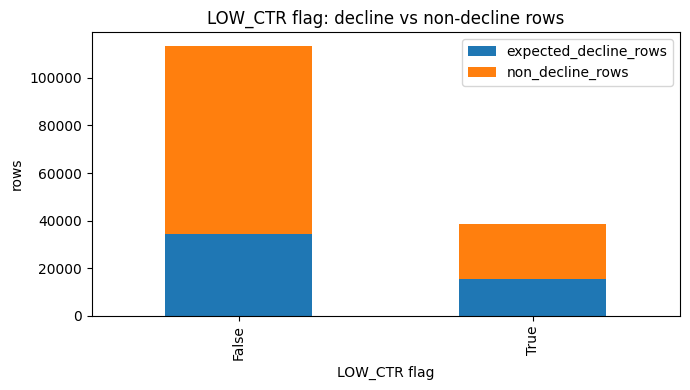

In [3]:
# Flag-linked test: LOW_CTR vs decline proxy.

import pandas as pd
import matplotlib.pyplot as plt

flag_test = pd.DataFrame({
    "low_ctr_flag": [False, True],
    "rows": [113486, 38495],
    "decline_rate": [0.301, 0.406],
})
flag_test["expected_decline_rows"] = (flag_test["rows"] * flag_test["decline_rate"]).round().astype(int)
flag_test["non_decline_rows"] = flag_test["rows"] - flag_test["expected_decline_rows"]

print("LOW_CTR flag audit")
display(flag_test)

lift = round(flag_test.loc[1, "decline_rate"] / flag_test.loc[0, "decline_rate"], 2)
abs_diff = round(flag_test.loc[1, "decline_rate"] - flag_test.loc[0, "decline_rate"], 3)
print(f"Observed risk lift for LOW_CTR rows vs other rows: {lift}x")
print(f"Absolute decline-rate gap: {abs_diff}")

plot_df = flag_test.set_index("low_ctr_flag")[["expected_decline_rows", "non_decline_rows"]]
ax = plot_df.plot(kind="bar", stacked=True, figsize=(7,4), title="LOW_CTR flag: decline vs non-decline rows")
ax.set_xlabel("LOW_CTR flag")
ax.set_ylabel("rows")
plt.tight_layout()
plt.show()


## 4. What this means in practice

A content team can use these signals to **order review work**, not to outsource judgment. Low CTR, weak position, and inconsistent activity all show directional evidence of higher decline risk, so they are reasonable components in a review queue.

The practical rule is conservative: treat the flags as **human-review prompts**. Prioritize pages with multiple weak signals, inspect them for title/snippet fit, ranking depth, topical gaps, and possible staleness, and keep low-evidence pages in monitoring rather than forcing an edit.


In [4]:
# Practical action summary.

import pandas as pd

actions = pd.DataFrame([
    ["Weak position + meaningful impressions", "Ranking-depth review", "Check topical gaps, competing results, internal links"],
    ["Low CTR + visibility already present", "CTR review", "Inspect title/snippet fit and SERP presentation"],
    ["Mixed or low-evidence signals", "Monitor", "Defer edits; collect another observation window"],
], columns=["Observed pattern", "Recommended action", "Human check"])

print("Action summary derived from the audit")
display(actions)
print("Guardrail: all outputs remain recommendation-only and require human review before any rewrite, redirect, or publish action.")


Action summary derived from the audit


,Observed pattern,Recommended action,Human check
0,Weak position + meaningful impressions,Ranking-depth review,"Check topical gaps, competing results, interna..."
1,Low CTR + visibility already present,CTR review,Inspect title/snippet fit and SERP presentation
2,Mixed or low-evidence signals,Monitor,Defer edits; collect another observation window


Guardrail: all outputs remain recommendation-only and require human review before any rewrite, redirect, or publish action.


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
